# Проект 4. Аттрактор Лоренца

В этом проекте численно решается систему Лоренца и строится её траекторию в трёхмерном пространстве.

Систему предложил метеоролог Эдвард Лоренц в 1963 году как сильно упрощённую модель конвекции в атмосфере. Она стала одним из первых примеров детерминированного хаоса: уравнения простые и без всякой случайности, а поведение решения всё равно непредсказуемо на длинных промежутках времени.

$$\begin{cases}
\dfrac{dx}{dt} = \sigma (y - x) \\[4pt]
\dfrac{dy}{dt} = x(\rho - z) - y \\[4pt]
\dfrac{dz}{dt} = xy - \beta z
\end{cases}$$

Параметры взяты классические: σ = 10, ρ = 28, β = 8/3, при них система ведёт себя хаотично. Начальная точка (0.1, 0, 0), время от 0 до 100.

Систему решается пакетом `DifferentialEquations.jl`, он сам подбирает численный метод и шаг. График строится через `Plots`.

In [ ]:
import Pkg
Pkg.add(["DifferentialEquations", "Plots"])

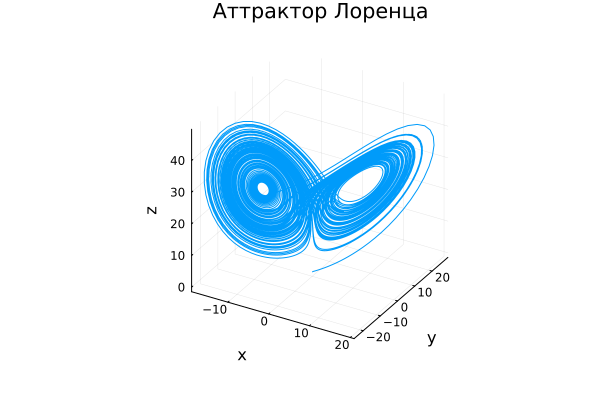

In [1]:
using DifferentialEquations, Plots

# Определяем систему уравнений
function lorenz!(du, u, p, t)
    σ, ρ, β = p
    du[1] = σ * (u[2] - u[1])
    du[2] = u[1] * (ρ - u[3]) - u[2]
    du[3] = u[1] * u[2] - β * u[3]
end

# Параметры и начальные условия
u0 = [0.1, 0.0, 0.0]
tspan = (0.0, 100.0)
p = [10.0, 28.0, 8/3]

# Решаем
prob = ODEProblem(lorenz!, u0, tspan, p)
sol = solve(prob, saveat=0.01)

# Визуализация
plot(sol, idxs=(1,2,3), title="Аттрактор Лоренца",
     xlabel="x", ylabel="y", zlabel="z", legend=false)

## Вывод

На графике получилась известная «бабочка». Траектория не улетает на бесконечность и не останавливается в одной точке, а всё время крутится вокруг двух точек равновесия, нерегулярно перескакивая с одного «крыла» на другое.

Главное свойство этой системы — чувствительность к начальным условиям. Если чуть-чуть сдвинуть начальную точку, через некоторое время траектория станет совсем другой. В этой работе это отдельно не проверялось, но именно из-за этого эффекта долгосрочный прогноз погоды невозможен, даже если уравнения известны точно.

Сама реализация на Julia оказалась короткой: нужно только описать правую часть системы в функции `lorenz!`, остальное делает `DifferentialEquations.jl`.